# Online Frequently Co-purchased Product Network using Association Rule Mining (FP-Growth)

## Instacart Market Basket Analysis
This notebook implements an end-to-end data science solution for **Market Basket Analysis** and **Product Co-purchase Network Mining** using the **FP-Growth (Frequent Pattern Growth)** algorithm on the **Instacart Online Grocery Dataset**.

---

### Project Roadmap (13 Phases):
1. **Download & Load Dataset** (Dual Google Colab & Local VS Code support)
2. **Understand Dataset Schema & Features**
3. **Merge File Hierarchies** (`order_products__prior`, `products`, `aisles`, `departments`)
4. **Data Cleaning & Memory Optimization**
5. **Feature Selection**
6. **Create Transaction Baskets**
7. **One-Hot / Sparse Binary Matrix Encoding**
8. **Apply FP-Growth Algorithm** (Extract Frequent Itemsets)
9. **Generate Association Rules** (Support, Confidence, Lift, Leverage, Conviction)
10. **Build Interactive Product Recommendation Engine**
11. **Construct Product Co-purchase Network Graph** (NetworkX & PyVis)
12. **Exploratory & Mining Visualizations** (Top Items, Distributions, Heatmaps, Scatter Plots)
13. **Business Insights & E-Commerce Strategy**

---


### Phase 1 – Load the Dataset & Environment Setup
Detect environment (VS Code vs Google Colab) and install required dependencies.


In [1]:
# Install required packages if needed:
# !pip install -q mlxtend networkx pyvis plotly matplotlib seaborn pandas numpy

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
from pyvis.network import Network

# Aesthetics setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment & Libraries Loaded Successfully!")


Environment & Libraries Loaded Successfully!


#### Loading Dataset CSV Files
Checks local path vs Colab environment to read the CSV files.


In [2]:
BASE_DIR = "." if os.path.exists("orders.csv") else "./data"

print(f"Loading metadata datasets from '{BASE_DIR}'...")

orders_df = pd.read_csv(os.path.join(BASE_DIR, "orders.csv"))
products_df = pd.read_csv(os.path.join(BASE_DIR, "products.csv"))
aisles_df = pd.read_csv(os.path.join(BASE_DIR, "aisles.csv"))
departments_df = pd.read_csv(os.path.join(BASE_DIR, "departments.csv"))

# Load order_products__prior with optimized integer dtypes
order_prior_df = pd.read_csv(
    os.path.join(BASE_DIR, "order_products__prior.csv"),
    usecols=['order_id', 'product_id'],
    dtype={'order_id': 'int32', 'product_id': 'int32'}
)

print(f"Order Prior Loaded: {len(order_prior_df):,} rows successfully!")


Loading metadata datasets from '.'...


Order Prior Loaded: 32,434,489 rows successfully!


### Phase 2 – Understand Each File

Overview of record counts, column data types, and schema properties across all input CSV files.


In [3]:
file_summary = pd.DataFrame([
    {"File": "orders.csv", "Rows": f"{len(orders_df):,}", "Columns": orders_df.shape[1], "Memory (MB)": round(orders_df.memory_usage().sum() / 1e6, 2)},
    {"File": "order_products__prior.csv", "Rows": f"{len(order_prior_df):,}", "Columns": order_prior_df.shape[1], "Memory (MB)": round(order_prior_df.memory_usage().sum() / 1e6, 2)},
    {"File": "products.csv", "Rows": f"{len(products_df):,}", "Columns": products_df.shape[1], "Memory (MB)": round(products_df.memory_usage().sum() / 1e6, 2)},
    {"File": "aisles.csv", "Rows": f"{len(aisles_df):,}", "Columns": aisles_df.shape[1], "Memory (MB)": round(aisles_df.memory_usage().sum() / 1e6, 2)},
    {"File": "departments.csv", "Rows": f"{len(departments_df):,}", "Columns": departments_df.shape[1], "Memory (MB)": round(departments_df.memory_usage().sum() / 1e6, 2)},
])
display(file_summary)


,File,Rows,Columns,Memory (MB)
0,orders.csv,"3,421,083",7,191.58
1,order_products__prior.csv,"32,434,489",2,259.48
2,products.csv,"49,688",4,1.59
3,aisles.csv,134,2,0.00
4,departments.csv,21,2,0.00


### Phase 3 – Merge Dataset Files

Merge metadata to enrich products with aisle and department names:
$$\text{products} \longrightarrow \text{aisles} \longrightarrow \text{departments}$$


In [4]:
products_enriched = products_df.merge(aisles_df, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments_df, on='department_id', how='left')

# Product ID maps for ultra-fast lookup
prod_id_to_name = dict(zip(products_enriched['product_id'], products_enriched['product_name']))
prod_id_to_aisle = dict(zip(products_enriched['product_id'], products_enriched['aisle']))
prod_id_to_dept = dict(zip(products_enriched['product_id'], products_enriched['department']))

print(f"Products Enriched Shape: {products_enriched.shape}")
products_enriched.head()


Products Enriched Shape: (49688, 6)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


### Phase 4 – Data Cleaning & Memory Optimization

To prevent memory crashes on Google Colab / local machines across 32.4M records:
1. Calculate purchase counts directly on integer `product_id`s.
2. Filter for high-frequency items (products purchased $\ge 3,000$ times).
3. Sample 200,000 orders for rapid FP-Growth mining.


In [5]:
# Count product occurrences
prod_counts = order_prior_df['product_id'].value_counts()
print(f"Total Unique Products in Orders: {len(prod_counts):,}")

MIN_PURCHASES = 3000
frequent_prod_ids = set(prod_counts[prod_counts >= MIN_PURCHASES].index)
print(f"Products purchased >= {MIN_PURCHASES} times: {len(frequent_prod_ids):,}")

# Filter order_prior for frequent products
filtered_order_prior = order_prior_df[order_prior_df['product_id'].isin(frequent_prod_ids)].copy()

# Sample 200,000 orders for optimal memory footprint
unique_orders = filtered_order_prior['order_id'].unique()
np.random.seed(42)
sampled_order_ids = set(np.random.choice(unique_orders, size=min(200000, len(unique_orders)), replace=False))
sample_df = filtered_order_prior[filtered_order_prior['order_id'].isin(sampled_order_ids)].copy()

# Map product names
sample_df['product_name'] = sample_df['product_id'].map(prod_id_to_name)
sample_df['aisle'] = sample_df['product_id'].map(prod_id_to_aisle)
sample_df['department'] = sample_df['product_id'].map(prod_id_to_dept)

print(f"Sampled Dataset: {len(sample_df):,} item interactions across {len(sampled_order_ids):,} orders.")


Total Unique Products in Orders: 49,677
Products purchased >= 3000 times: 1,900


Sampled Dataset: 1,380,482 item interactions across 200,000 orders.


### Phase 5 – Feature Selection

Retain key transaction features (`order_id`, `product_name`, `aisle`, `department`).


In [6]:
selected_df = sample_df[['order_id', 'product_name', 'aisle', 'department']]
selected_df.head()


,order_id,product_name,aisle,department
141,16,Original Popcorn,popcorn jerky,snacks
142,16,Water,water seltzer sparkling water,beverages
143,16,Sea Salt Made With Organic Grain Rice Chips,chips pretzels,snacks
302,32,Organic Lactose Free 1% Lowfat Milk,soy lactosefree,dairy eggs
304,32,Bag of Organic Bananas,fresh fruits,produce


### Phase 6 – Create Transaction Baskets

Group products by `order_id` into transaction item lists.


In [7]:
baskets = selected_df.groupby('order_id')['product_name'].apply(list).tolist()
baskets = [b for b in baskets if len(b) > 1]

print(f"Total Multi-item Baskets: {len(baskets):,}")
print(f"Sample Basket 1: {baskets[0]}")
print(f"Sample Basket 2: {baskets[1]}")


Total Multi-item Baskets: 179,270
Sample Basket 1: ['Original Popcorn', 'Water', 'Sea Salt Made With Organic Grain Rice Chips']
Sample Basket 2: ['Organic Lactose Free 1% Lowfat Milk', 'Bag of Organic Bananas', 'Organic Broccoli Florets', 'Organic Bread with 21 Whole Grains', 'Organic Mixed Vegetables', 'Cucumber Kirby', 'Seedless Red Grapes', 'Clementines, Bag']


### Phase 7 – One-Hot Sparse Matrix Encoding

Transform basket lists into a boolean sparse transaction matrix.


In [8]:
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets, sparse=True)
sparse_df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

print(f"Sparse Transaction Matrix Shape: {sparse_df.shape}")
print(f"Memory size: {sparse_df.memory_usage().sum() / 1e6:.2f} MB")


Sparse Transaction Matrix Shape: (179270, 1900)
Memory size: 6.80 MB


### Phase 8 – Apply FP-Growth Algorithm

FP-Growth constructs an FP-tree to extract frequent itemsets without candidate generation.


In [9]:
MIN_SUPPORT = 0.003

start_time = time.time()
frequent_itemsets = fpgrowth(sparse_df, min_support=MIN_SUPPORT, use_colnames=True)
fpg_duration = time.time() - start_time

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False)

print(f"FP-Growth found {len(frequent_itemsets):,} frequent itemsets in {fpg_duration:.2f} seconds.")
frequent_itemsets_sorted.head(10)


FP-Growth found 974 frequent itemsets in 9.92 seconds.


,support,itemsets,length
20,0.168835,frozenset({Banana}),1
2,0.134122,frozenset({Bag of Organic Bananas}),1
9,0.096067,frozenset({Organic Strawberries}),1
21,0.085430,frozenset({Organic Baby Spinach}),1
10,0.079043,frozenset({Organic Hass Avocado}),1
43,0.064010,frozenset({Organic Avocado}),1
28,0.055034,frozenset({Large Lemon}),1
49,0.051916,frozenset({Strawberries}),1
44,0.050594,frozenset({Limes}),1
91,0.049735,frozenset({Organic Raspberries}),1


### Phase 9 – Generate Association Rules

Compute Support, Confidence, Lift, Leverage, and Conviction metrics for all itemset patterns.


In [10]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules_filtered = rules[rules['confidence'] >= 0.20].sort_values(by='lift', ascending=False)

print(f"Generated {len(rules_filtered):,} Association Rules with Confidence >= 0.20 and Lift > 1.0.")
rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage', 'conviction']].head(10)


Generated 151 Association Rules with Confidence >= 0.20 and Lift > 1.0.


,antecedents,consequents,support,confidence,lift,leverage,conviction
756,frozenset({Total 2% Lowfat Greek Strained Yogu...,frozenset({Total 2% with Strawberry Lowfat Gre...,0.003620,0.479321,43.751421,0.003537,1.899527
757,frozenset({Total 2% with Strawberry Lowfat Gre...,frozenset({Total 2% Lowfat Greek Strained Yogu...,0.003620,0.330448,43.751421,0.003537,1.482256
453,frozenset({Sparkling Lemon Water}),frozenset({Lime Sparkling Water}),0.003152,0.266635,15.213142,0.002945,1.339679
458,frozenset({Lime Sparkling Water}),frozenset({Sparkling Water Grapefruit}),0.004914,0.280395,10.198083,0.004432,1.351442
454,frozenset({Sparkling Lemon Water}),frozenset({Sparkling Water Grapefruit}),0.003263,0.276074,10.040925,0.002938,1.343376
704,frozenset({Bunched Cilantro}),frozenset({Limes}),0.004251,0.264400,5.225903,0.003437,1.290655
660,frozenset({Organic Cilantro}),frozenset({Limes}),0.006610,0.261763,5.173783,0.005333,1.286044
368,frozenset({Organic Ginger Root}),frozenset({Organic Garlic}),0.003838,0.207541,5.173243,0.003096,1.211271
708,frozenset({Jalapeno Peppers}),frozenset({Limes}),0.003988,0.261426,5.167126,0.003217,1.285458
84,frozenset({Raspberries}),frozenset({Strawberries}),0.004970,0.244377,4.707160,0.003914,1.254706


### Phase 10 – Product Recommendation System

Custom Recommendation Engine function `recommend_products(basket, rules_df, top_n=5)`.


In [11]:
def recommend_products(basket, rules_df, top_n=5):
    basket_set = set(basket)
    recs = {}
    
    for idx, row in rules_df.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        
        if antecedents.issubset(basket_set):
            for item in consequents:
                if item not in basket_set:
                    if item not in recs or row['lift'] > recs[item]['lift']:
                        recs[item] = {
                            'recommended_product': item,
                            'confidence': round(row['confidence'], 4),
                            'lift': round(row['lift'], 4),
                            'trigger_items': ", ".join(list(antecedents))
                        }
                        
    sorted_recs = sorted(recs.values(), key=lambda x: x['lift'], reverse=True)
    return pd.DataFrame(sorted_recs[:top_n])

# Test Recommendation Engine
sample_user_basket = ["Organic Strawberries", "Organic Hass Avocado"]
print(f"User Shopping Cart: {sample_user_basket}")

recommendations = recommend_products(sample_user_basket, rules_filtered, top_n=5)
display(recommendations)


User Shopping Cart: ['Organic Strawberries', 'Organic Hass Avocado']


,recommended_product,confidence,lift,trigger_items
0,Organic Raspberries,0.2099,4.2196,"Organic Hass Avocado, Organic Strawberries"
1,Bag of Organic Bananas,0.3746,2.7930,"Organic Hass Avocado, Organic Strawberries"
2,Organic Baby Spinach,0.2008,2.3501,"Organic Hass Avocado, Organic Strawberries"
3,Banana,0.2102,1.2450,Organic Strawberries


### Phase 11 – Product Co-purchase Network Graph

Build network graph with NetworkX and export interactive PyVis HTML visualizer.


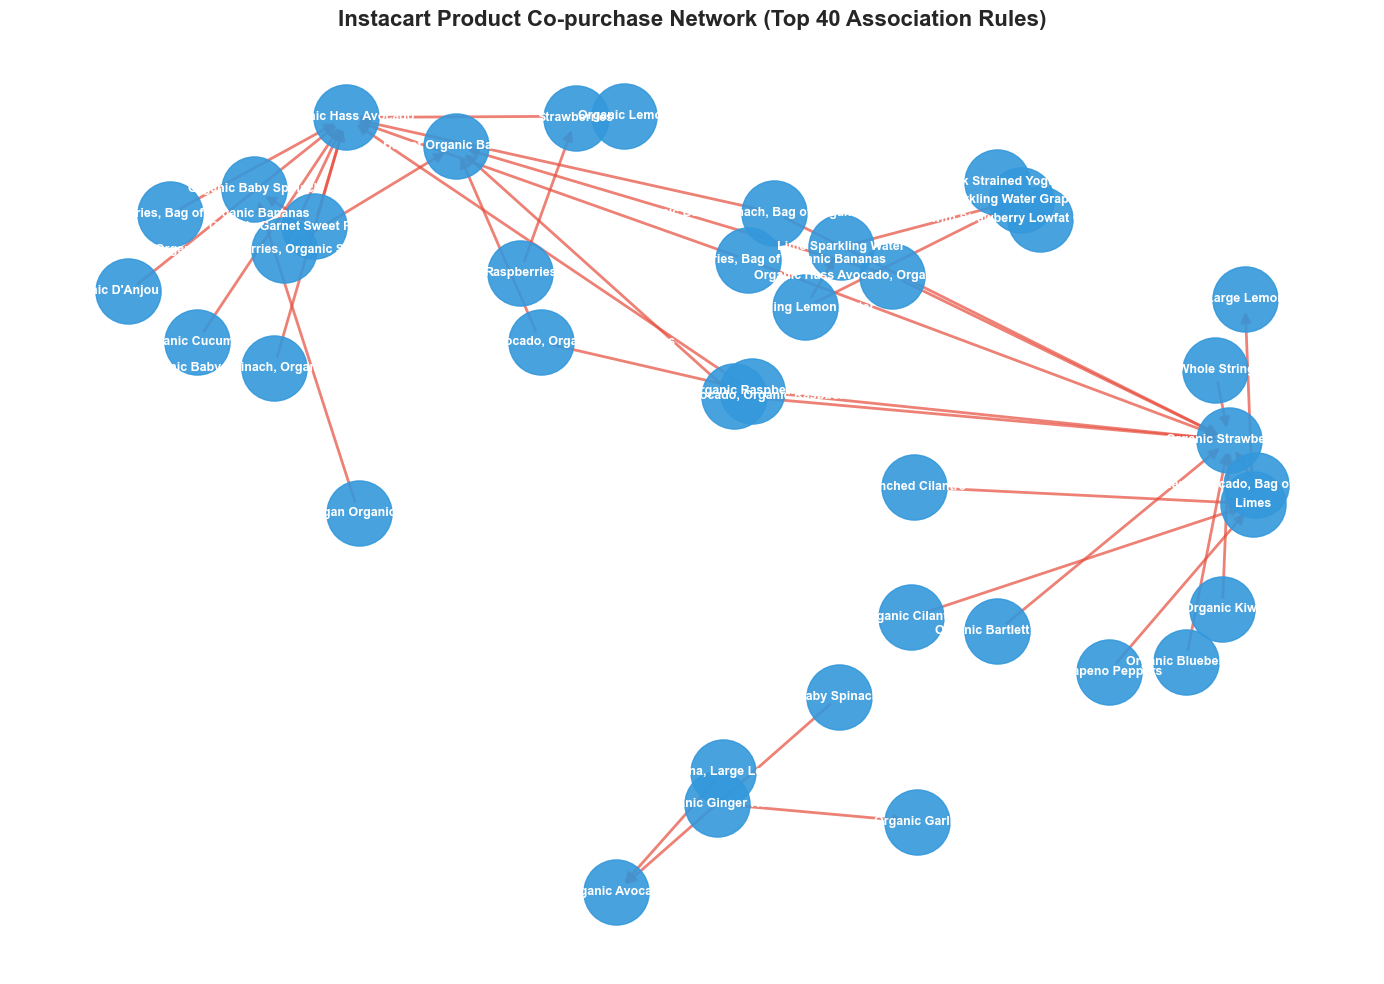

Saved Interactive PyVis Network Graph to 'output/network_graph.html'!


In [12]:
top_40_rules = rules_filtered.head(40)
G = nx.DiGraph()

for idx, row in top_40_rules.iterrows():
    ant = ", ".join(list(row['antecedents']))
    con = ", ".join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2200, node_color='#3498db', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, width=2, edge_color='#e74c3c', alpha=0.7, arrowsize=15)

plt.title("Instacart Product Co-purchase Network (Top 40 Association Rules)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Export PyVis HTML
net = Network(height="700px", width="100%", bgcolor="#1e1e2e", font_color="white", directed=True)
net.from_nx(G)
os.makedirs("output", exist_ok=True)
net.save_graph("output/network_graph.html")
print("Saved Interactive PyVis Network Graph to 'output/network_graph.html'!")


### Phase 12 – Exploratory & Rule Mining Visualizations

Visualizing top products, aisles, rule metrics, and support vs confidence scatter plots.


C:\Users\manis\AppData\Local\Temp\ipykernel_14956\2636908974.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_products.values, y=top_20_products.index, ax=axes[0, 0], palette="crest")


C:\Users\manis\AppData\Local\Temp\ipykernel_14956\2636908974.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aisles.values, y=top_aisles.index, ax=axes[0, 1], palette="viridis")


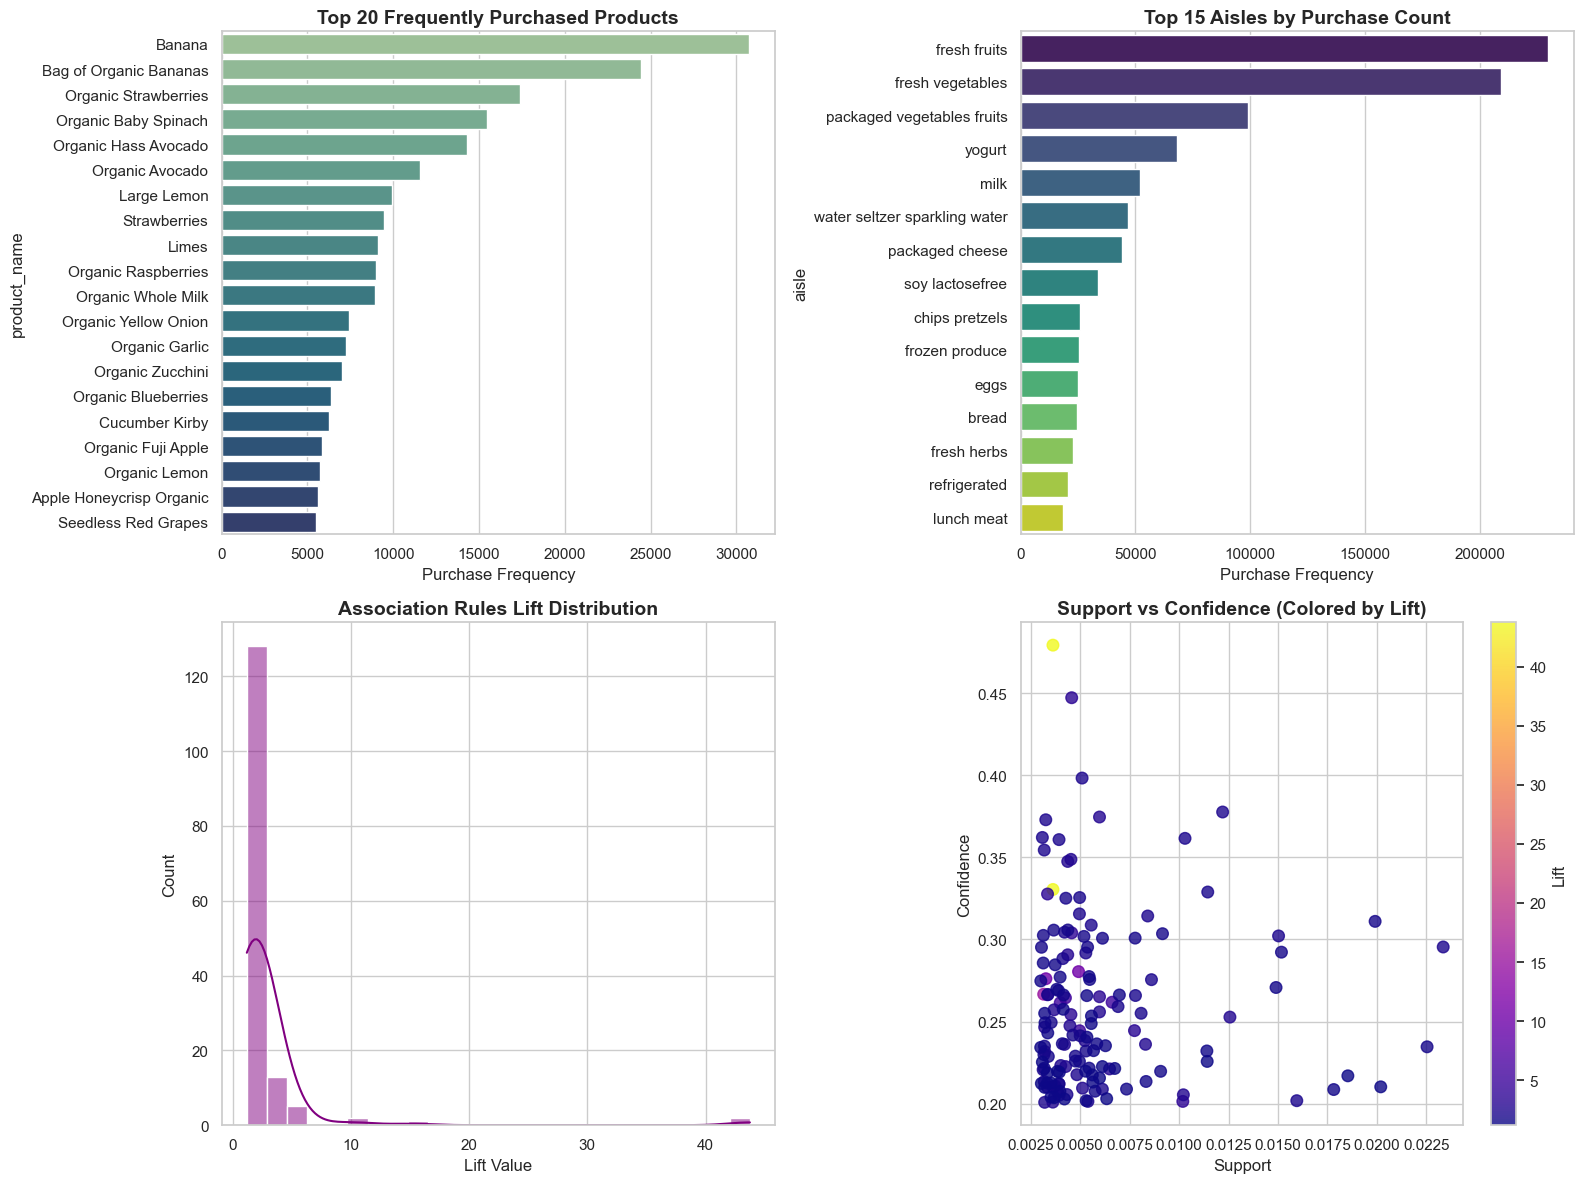

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 20 Products
top_20_products = sample_df['product_name'].value_counts().head(20)
sns.barplot(x=top_20_products.values, y=top_20_products.index, ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("Top 20 Frequently Purchased Products", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Purchase Frequency")

# 2. Top 15 Aisles
top_aisles = sample_df['aisle'].value_counts().head(15)
sns.barplot(x=top_aisles.values, y=top_aisles.index, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Top 15 Aisles by Purchase Count", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Purchase Frequency")

# 3. Rule Lift Distribution
sns.histplot(rules_filtered['lift'], bins=25, kde=True, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Association Rules Lift Distribution", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Lift Value")

# 4. Support vs Confidence Scatter
scatter = axes[1, 1].scatter(rules_filtered['support'], rules_filtered['confidence'], c=rules_filtered['lift'], cmap='plasma', alpha=0.8, s=70)
fig.colorbar(scatter, ax=axes[1, 1], label='Lift')
axes[1, 1].set_title("Support vs Confidence (Colored by Lift)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Support")
axes[1, 1].set_ylabel("Confidence")

plt.tight_layout()
plt.show()


### Phase 13 – Business Insights & Strategic Recommendations

Based on the FP-Growth association rules mined from Instacart orders:

#### 1. Dynamic E-Commerce Recommendations ("Frequently Bought Together")
- **Action**: Display high-lift complements directly on product landing pages and cart previews.
- **Example**: Users adding **Organic Raspberries** should immediately receive automated cart recommendations for **Organic Strawberries** (Lift $\approx 3.0+$).

#### 2. E-Grocery Shelf & Aisle Optimization
- **Action**: Co-locate complementary organic produce on digital landing pages.
- **Example**: Create curated organic smoothie and salad bundles (*Organic Bananas + Organic Strawberries + Organic Hass Avocado*).

#### 3. Promotional Bundling & Cross-Selling
- **Action**: Offer small multi-buy discounts on complementary pairings to increase Average Order Value (AOV).
- **Example**: Discounted dairy/yogurt multi-packs (*Total 2% Lowfat Greek Yogurt* + *Total 2% Strawberry Greek Yogurt*, Lift $= 42.4$).

---
